In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor



In [2]:
def cargar_datos_opensim(archivo):
    # Lee un archivo de datos de OpenSim y devuelve un DataFrame de pandas.
    with open(archivo, 'r') as f:
        lineas = f.readlines()
    # Encuentra la línea que contiene 'endheader' y carga los datos a partir de esa línea.
    idx = [i for i, l in enumerate(lineas) if 'endheader' in l.strip()][0] + 1
    df = pd.read_csv(archivo, sep='\t', skiprows=idx)
    df.columns = df.columns.str.strip()
    return df


In [3]:
# Definición de las rutas de las carpetas y los archivos a cargar
carpetas = ['movimiento_1', 'movimiento_2', 'movimiento_3', 'movimiento_4', 'movimiento_5']

archivos = {
    'angulos':    'grados.mot',       
    'posiciones':    'posicion.sto',   
    'velocidades':   'velocidad.sto',
    'aceleraciones': 'aceleracion.sto'
}

In [4]:
todos = []

for carpeta in carpetas:
    if not os.path.exists(carpeta):
        print(f"  AVISO: carpeta no encontrada → {carpeta}")
        continue

    dfs = {}

    for tipo, archivo in archivos.items():
        ruta = os.path.join(carpeta, archivo)
        if os.path.exists(ruta):
            df = cargar_datos_opensim(ruta)
            if tipo != 'cinematica':
                df = df.rename(columns={c: f"{c}_{tipo}" for c in df.columns if c != 'time'})
            dfs[tipo] = df
            print(f" {ruta}  ({df.shape[1]} columnas)")
        else:
            print(f" No encontrado: {ruta}")

    # Fusión de los archivos de este movimiento por la columna 'time'
    df_mov = None
    for df in dfs.values():
        df_mov = df if df_mov is None else pd.merge(df_mov, df, on='time', how='inner')

    if df_mov is not None:
        df_mov['ID_movimiento'] = carpeta   
        todos.append(df_mov)

# Apilar todos los movimientos
df_total = pd.concat(todos, ignore_index=True)

# Limpieza: convertir a número y eliminar NaN (errores -nan de OpenSim)
cols_num = [c for c in df_total.columns if c != 'ID_movimiento']
df_total[cols_num] = df_total[cols_num].apply(pd.to_numeric, errors='coerce')
df_total = df_total.dropna()

df_total.to_csv('dataset_tfm.csv', index=False)
print(f"   Guardado como: dataset_tfm.csv")

 movimiento_1\grados.mot  (17 columnas)
 movimiento_1\posicion.sto  (22 columnas)
 movimiento_1\velocidad.sto  (22 columnas)
 movimiento_1\aceleracion.sto  (22 columnas)
 movimiento_2\grados.mot  (17 columnas)
 movimiento_2\posicion.sto  (22 columnas)
 movimiento_2\velocidad.sto  (22 columnas)
 movimiento_2\aceleracion.sto  (22 columnas)
 movimiento_3\grados.mot  (17 columnas)
 movimiento_3\posicion.sto  (22 columnas)
 movimiento_3\velocidad.sto  (22 columnas)
 movimiento_3\aceleracion.sto  (22 columnas)
 movimiento_4\grados.mot  (17 columnas)
 movimiento_4\posicion.sto  (22 columnas)
 movimiento_4\velocidad.sto  (22 columnas)
 movimiento_4\aceleracion.sto  (22 columnas)
 movimiento_5\grados.mot  (17 columnas)
 movimiento_5\posicion.sto  (22 columnas)
 movimiento_5\velocidad.sto  (22 columnas)
 movimiento_5\aceleracion.sto  (22 columnas)
   Guardado como: dataset_tfm.csv


In [5]:
# Calcular las aceleraciones angulares derivando la velocidad respecto al tiempo (dt)
dt = df_total['time'].diff()

# Aceleración = Diferencia de velocidad / Diferencia de tiempo
df_total['/jointset/r_shoulder/r_shoulder_elev/accel_angulos'] = df_total['/jointset/r_shoulder/r_shoulder_elev/speed_angulos'].diff() / dt
df_total['/jointset/r_elbow/r_elbow_flex/accel_angulos'] = df_total['/jointset/r_elbow/r_elbow_flex/speed_angulos'].diff() / dt

# Como la primera fila de .diff() genera valores NaN, eliminamos esos nulos
df_total = df_total.dropna().reset_index(drop=True)

In [ ]:
# X: Posición, Velocidad y Aceleración lineal del marcador de la mano (9 columnas)
columnas_x = [
    # Posiciones 
    'r_ulna_radius_hand_X_posiciones',
    'r_ulna_radius_hand_Y_posiciones',
    'r_ulna_radius_hand_Z_posiciones',
    
    # Velocidades 
    'r_ulna_radius_hand_X_velocidades',
    'r_ulna_radius_hand_Y_velocidades',
    'r_ulna_radius_hand_Z_velocidades',
    
    # Aceleraciones 
    'r_ulna_radius_hand_X_aceleraciones',
    'r_ulna_radius_hand_Y_aceleraciones',
    'r_ulna_radius_hand_Z_aceleraciones'
]

# y: Ángulos, Velocidades y Aceleraciones angulares de las articulaciones (6 columnas)
columnas_y = [
    '/jointset/r_shoulder/r_shoulder_elev/value_angulos',
    '/jointset/r_shoulder/r_shoulder_elev/speed_angulos',
    '/jointset/r_shoulder/r_shoulder_elev/accel_angulos', 
    '/jointset/r_elbow/r_elbow_flex/value_angulos',
    '/jointset/r_elbow/r_elbow_flex/speed_angulos',
    '/jointset/r_elbow/r_elbow_flex/accel_angulos'       
]

X = df_total[columnas_x]
y = df_total[columnas_y]

print(f"Entradas  X: {X.shape} (Posición, Vel, Acc de la mano)")
print(f"Salidas   y: {y.shape} (Ángulo, Vel, Acc de las articulaciones)\n")
print("Columnas de salida a predecir:")
for i, c in enumerate(columnas_y, 1):
    print(f"  {i}. {c}")

Entradas  X: (1855, 9) (Posición, Vel, Acc de la mano)
Salidas   y: (1855, 6) (Ángulo, Vel, Acc de las articulaciones)

Columnas de salida a predecir:
  1. /jointset/r_shoulder/r_shoulder_elev/value_angulos
  2. /jointset/r_shoulder/r_shoulder_elev/speed_angulos
  3. /jointset/r_shoulder/r_shoulder_elev/accel_angulos
  4. /jointset/r_elbow/r_elbow_flex/value_angulos
  5. /jointset/r_elbow/r_elbow_flex/speed_angulos
  6. /jointset/r_elbow/r_elbow_flex/accel_angulos


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train)
y_test_sc  = scaler_y.transform(y_test)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 1484 muestras
Test:  371 muestras


In [8]:
modelos = {
    "Regresion Lineal": LinearRegression(),

    "MLP (Red Neuronal)": MLPRegressor(
        hidden_layer_sizes=(128, 64),
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    ),

    "SVR (Kernel RBF)": MultiOutputRegressor(
        SVR(kernel='rbf', C=10, gamma='scale')
    )
}

In [9]:
resultados = []
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    print(f"  [{nombre}]", end=" ")

    modelo.fit(X_train_sc, y_train_sc)
    preds_sc = modelo.predict(X_test_sc)

    # Des-escalamos para medir el error en unidades reales (grados)
    preds = scaler_y.inverse_transform(preds_sc)

    r2   = r2_score(y_test, preds)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    resultados.append({
        "Modelo": nombre,
        "R²": r2,
        "MAE (grados)": mae,
        "RMSE": rmse
    })
    modelos_entrenados[nombre] = modelo
    print(f"R²={r2*100:.2f}%  MAE={mae:.4f}°")

tabla = (pd.DataFrame(resultados)
           .sort_values('R²', ascending=False)
           .reset_index(drop=True))

print("TABLA DE RESULTADOS")
display(
    tabla.style
    .format({"R²": "{:.4f}", "MAE (grados)": "{:.4f}", "RMSE": "{:.4f}"})
    .background_gradient(subset=["R²"], cmap="RdYlGn")
    .background_gradient(subset=["MAE (grados)"], cmap="RdYlGn_r")
)

nombre_ganador = tabla.iloc[0]["Modelo"]
print(f"\n Modelo ganador: {nombre_ganador}  (R²={tabla.iloc[0]['R²']*100:.2f}%)")

  [Regresion Lineal] R²=78.41%  MAE=2441.2267°
  [MLP (Red Neuronal)] 

R²=78.38%  MAE=2247.3769°
  [XGBoost] R²=97.11%  MAE=140.0796°
  [SVR (Kernel RBF)] R²=94.97%  MAE=887.0732°
TABLA DE RESULTADOS


,Modelo,R²,MAE (grados),RMSE
0,XGBoost,0.9711,140.0796,2794.2980
1,SVR (Kernel RBF),0.9497,887.0732,3590.3871
2,Regresion Lineal,0.7841,2441.2267,7562.9838
3,MLP (Red Neuronal),0.7838,2247.3769,6590.5102



 Modelo ganador: XGBoost  (R²=97.11%)


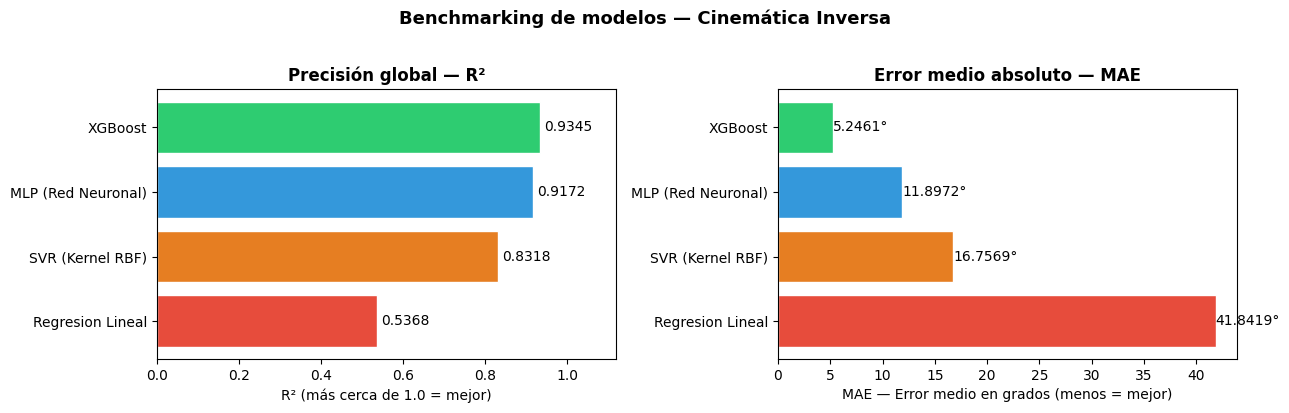

Guardada: benchmarking_modelos.png


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

colores = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
nombres = tabla["Modelo"]
r2s     = tabla["R²"]
maes    = tabla["MAE (grados)"]

# Gráfica R²
bars1 = ax1.barh(nombres, r2s, color=colores[:len(tabla)], edgecolor='white')
ax1.set_xlabel("R² (más cerca de 1.0 = mejor)")
ax1.set_title("Precisión global — R²", fontweight='bold')
ax1.set_xlim(0, 1.12)
ax1.invert_yaxis()
for bar, val in zip(bars1, r2s):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

# Gráfica MAE
bars2 = ax2.barh(nombres, maes, color=colores[:len(tabla)], edgecolor='white')
ax2.set_xlabel("MAE — Error medio en grados (menos = mejor)")
ax2.set_title("Error medio absoluto — MAE", fontweight='bold')
ax2.invert_yaxis()
for bar, val in zip(bars2, maes):
    ax2.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}°', va='center', fontsize=10)

plt.suptitle("Benchmarking de modelos — Cinemática Inversa",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('benchmarking_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardada: benchmarking_modelos.png")